# STEP 1 : IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 2 : LOAD DATASET

In [2]:
df = pd.read_csv("merged.csv")
#crude = pd.read_csv("crude.csv")
#brent = pd.read_csv("brent.csv")

# STEP 3 : BASIC INSPECTION

In [9]:
df.head()

,Date,OpenBrent,HighBrent,LowBrent,CloseBrent,VolumeBrent,OpenCrude,HighCrude,LowCrude,CloseCrude,...,OpenHeating,HighHeating,LowHeating,CloseHeating,VolumeHeating,OpenNatural,HighNatural,LowNatura,CloseNatural,VolumeNatural
0,2000-01-04,23.90,24.70,23.89,24.39,32509,25.20,25.69,24.71,25.55,...,0.6720,0.6830,0.6540,0.6778,25311,2.130,2.200,2.130,2.176,30152
1,2000-01-05,24.25,24.37,23.70,23.73,30310,25.50,25.61,24.87,24.91,...,0.6790,0.6790,0.6650,0.6655,18691,2.180,2.200,2.125,2.168,27946
2,2000-01-06,23.55,24.22,23.35,23.62,44662,24.80,25.34,24.51,24.78,...,0.6645,0.6830,0.6550,0.6628,27082,2.165,2.220,2.135,2.196,29071
3,2000-01-07,23.57,23.98,23.05,23.09,34826,24.65,25.00,24.15,24.22,...,0.6600,0.6710,0.6460,0.6475,26320,2.195,2.230,2.155,2.173,28455
4,2000-01-10,23.04,23.78,23.04,23.73,26388,24.22,24.75,24.02,24.67,...,0.6445,0.6535,0.6355,0.6472,20721,2.180,2.255,2.165,2.216,28916


In [13]:
df.columns

Index(['Date', 'OpenBrent', 'HighBrent', 'LowBrent', 'CloseBrent',
       'VolumeBrent', 'OpenCrude', 'HighCrude', 'LowCrude', 'CloseCrude',
       'VolumeCrude', 'OpenHeating', 'HighHeating', 'LowHeating',
       'CloseHeating', 'VolumeHeating', 'OpenNatural', 'HighNatural',
       'LowNatura', 'CloseNatural', 'VolumeNatural'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5588 entries, 0 to 5587
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           5588 non-null   object 
 1   OpenBrent      5588 non-null   float64
 2   HighBrent      5588 non-null   float64
 3   LowBrent       5588 non-null   float64
 4   CloseBrent     5588 non-null   float64
 5   VolumeBrent    5588 non-null   int64  
 6   OpenCrude      5588 non-null   float64
 7   HighCrude      5588 non-null   float64
 8   LowCrude       5588 non-null   float64
 9   CloseCrude     5588 non-null   float64
 10  VolumeCrude    5588 non-null   int64  
 11  OpenHeating    5588 non-null   float64
 12  HighHeating    5588 non-null   float64
 13  LowHeating     5588 non-null   float64
 14  CloseHeating   5588 non-null   float64
 15  VolumeHeating  5588 non-null   int64  
 16  OpenNatural    5588 non-null   float64
 17  HighNatural    5588 non-null   float64
 18  LowNatur

# STEP 4 : DATA CLEANING

In [40]:
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

In [41]:
df.isnull().sum()

Date                 0
OpenBrent            0
HighBrent            0
LowBrent             0
CloseBrent           0
VolumeBrent          0
OpenCrude            0
HighCrude            0
LowCrude             0
CloseCrude           0
VolumeCrude          0
OpenHeating          0
HighHeating          0
LowHeating           0
CloseHeating         0
VolumeHeating        0
OpenNatural          0
HighNatural          0
LowNatural           0
CloseNatural         0
VolumeNatural        0
Year                 0
Month                0
Crude_Return         1
Brent_Return         1
Heating_Return       1
Natural_Return       1
Crude_MA            29
Crude_Volatility    30
dtype: int64

In [42]:
df.drop_duplicates(inplace=True)

# STEP 5 : RENAME COLUMNS

In [24]:
df.rename(columns={'LowNatura': 'LowNatural'}, inplace=True)

# STEP 6 : FEATURE ENGINEERING

### Add time features

In [19]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

### Add Returns

In [26]:
df['Crude_Return'] = df['CloseCrude'].pct_change()
df['Brent_Return'] = df['CloseBrent'].pct_change()
df['Heating_Return'] = df['CloseHeating'].pct_change()
df['Natural_Return'] = df['CloseNatural'].pct_change()

# STEP 7 : EXPLORATORY DATA ANALYSIS

#### 1.Trend Analysis

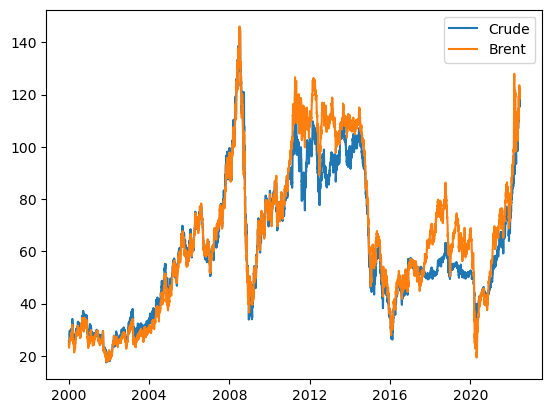

In [28]:
plt.figure()
plt.plot(df['Date'], df['CloseCrude'], label='Crude')
plt.plot(df['Date'], df['CloseBrent'], label='Brent')
plt.legend()
plt.show()

#### 2.Correlation Analysis

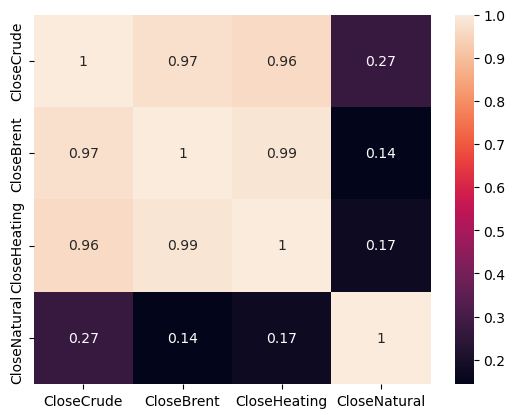

In [44]:
corr = df[['CloseCrude','CloseBrent','CloseHeating','CloseNatural']].corr()
sns.heatmap(corr, annot=True)
plt.show()

#### 3.Monthly Analysis

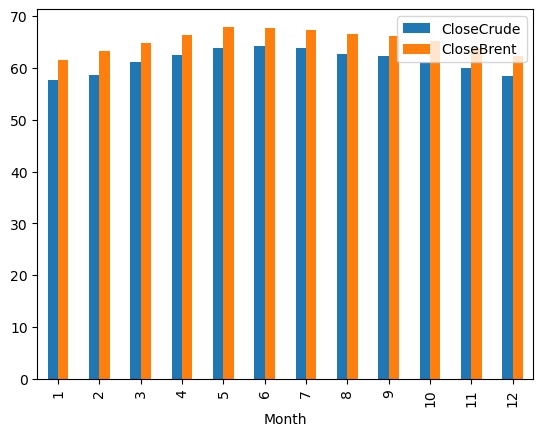

In [31]:
monthly = df.groupby('Month')[['CloseCrude','CloseBrent']].mean()
monthly.plot(kind='bar')
plt.show()

#### 4.Outliers

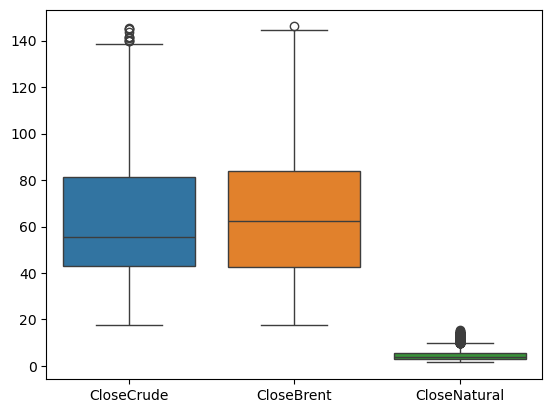

In [34]:
sns.boxplot(data=df[['CloseCrude','CloseBrent','CloseNatural']])
plt.show()

### 5.Moving Average

In [36]:
df['Crude_MA'] = df['CloseCrude'].rolling(window=30).mean()

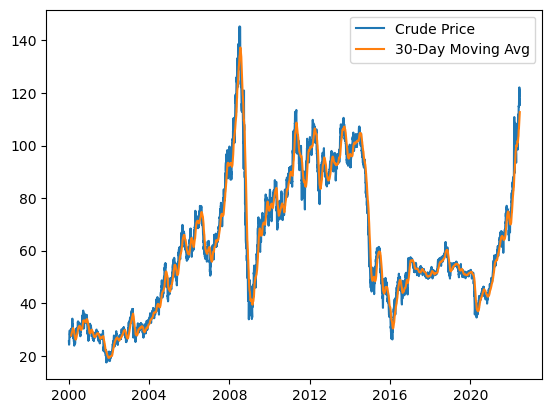

In [38]:
plt.figure()
plt.plot(df['Date'], df['CloseCrude'], label='Crude Price')
plt.plot(df['Date'], df['Crude_MA'], label='30-Day Moving Avg')
plt.legend()
plt.show()

### 6.Volatility

In [37]:
df['Crude_Volatility'] = df['Crude_Return'].rolling(window=30).std()

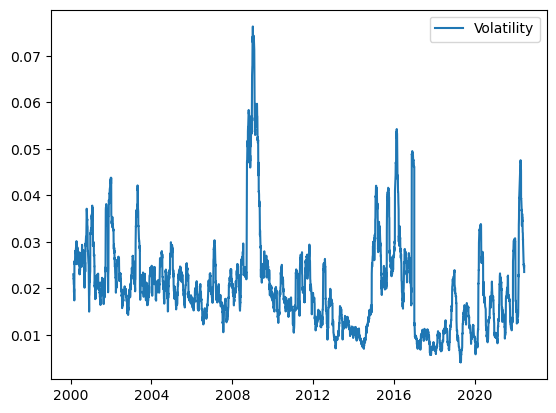

In [39]:
plt.figure()
plt.plot(df['Date'], df['Crude_Volatility'], label='Volatility')
plt.legend()
plt.show()